In [33]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table

In [34]:
catalog_dir = "/home/alab_student/Tim/Projects/Catalogs/"
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/"

In [35]:
def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog

In [ ]:
Matched_Fits_Fermi_only = Table.read(outdir + 'Blazar_Fitter_out/Matched_Fits_Fermi_Only/Matched_Fits_Fermi_only_results.fits')

In [37]:
Matched_Blazar_Fit_All = Table.read(outdir + 'Blazar_Fitter_out/Matched_Blazar_Fits_All/MeV_Blazar_Fits_All_results.fits')
Matched_Blazar_Fit_All.pprint_all()

          Name          Class       Alpha              Alpha_Err                Beta                 Beta_Err           IC_Peak_Energy       IC_Peak_Energy_Err   IC_Peak_Energy_Flux            Chi2         
----------------------- ----- ------------------ --------------------- ---------------------- --------------------- ---------------------- --------------------- ---------------------- ----------------------
           1ES 0033+595   bll  2.464397258702322    0.0139830278645407  -0.024742504753178567 0.0009929641080672885                   None                  None                   None   6.59620476171133e-06
        RX J0115.7+2519   bll 2.0701342881999643   0.03375956054851627 -0.0037190492882141135 0.0019780382128528682                   None                  None                   None  8.530994205772787e-06
           1ES 0120+340   bll  2.701283632242646    0.0569648100132727  -0.035524232360088386  0.004013611067589626                   None                  None            

In [38]:
Matched_Blazar_Fit_FSRQ, Matched_Blazar_Fit_BLL, Matched_Blazar_Fit_BCU = mask_catalog_by_class(Matched_Blazar_Fit_All, 'Class')
Matched_Blazar_Fit_Catalogs_by_class = [Matched_Blazar_Fit_FSRQ, Matched_Blazar_Fit_BLL, Matched_Blazar_Fit_BCU]

In [39]:
colors = ['blue','red','purple']
labels = ['fsrq','bll','bcu']

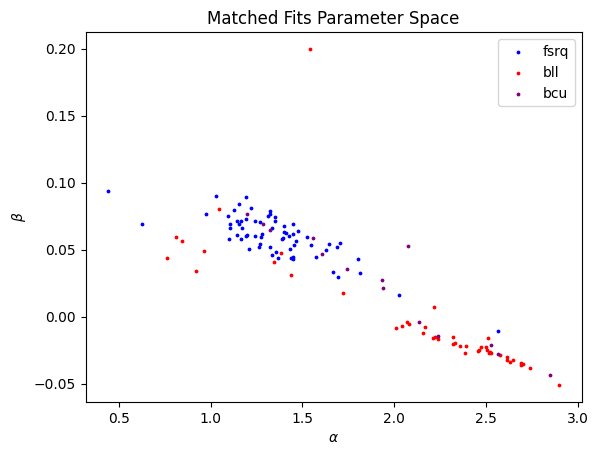

In [40]:
for i in range(len(Matched_Blazar_Fit_Catalogs_by_class)):
    alpha = Matched_Blazar_Fit_Catalogs_by_class[i]['Alpha'].tolist()
    beta = Matched_Blazar_Fit_Catalogs_by_class[i]['Beta'].tolist()

    plt.scatter(alpha, beta, color = colors[i], label = labels[i], s = 3)
    
#plt.title
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\beta$')
plt.legend(loc='upper right')
plt.title('Matched Fits Parameter Space')
plt.savefig(outdir + 'Matched_Fits_Parameter_Space.png')

In [41]:
Matched_Fits_Fermi_only_FSRQ, Matched_Fits_Fermi_only_BLL, Matched_Fits_Fermi_only_BCU = mask_catalog_by_class(Matched_Fits_Fermi_only, 'Class')
Matched_Fits_Fermi_all = [Matched_Fits_Fermi_only_FSRQ, Matched_Fits_Fermi_only_BLL, Matched_Fits_Fermi_only_BCU]

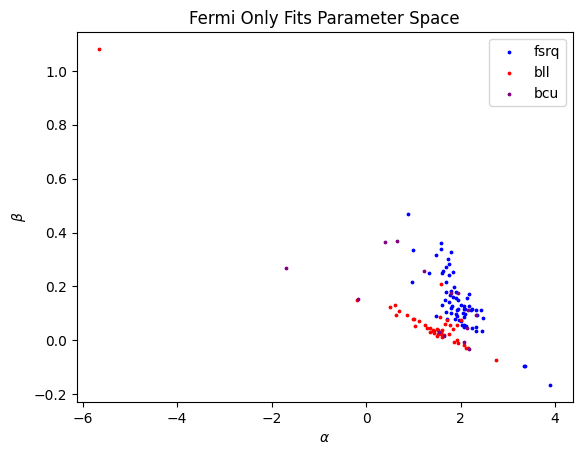

In [42]:
for i in range(len(Matched_Fits_Fermi_all)):
    alpha = Matched_Fits_Fermi_all[i]['Alpha'].tolist()
    beta = Matched_Fits_Fermi_all[i]['Beta'].tolist()

    plt.scatter(alpha, beta, color = colors[i], label = labels[i], s = 3)
    
#plt.title
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\beta$')
plt.legend(loc='upper right')
plt.title('Fermi Only Fits Parameter Space')
plt.savefig(outdir + 'Fermi_Only_Fits_Parameter_Space.png')

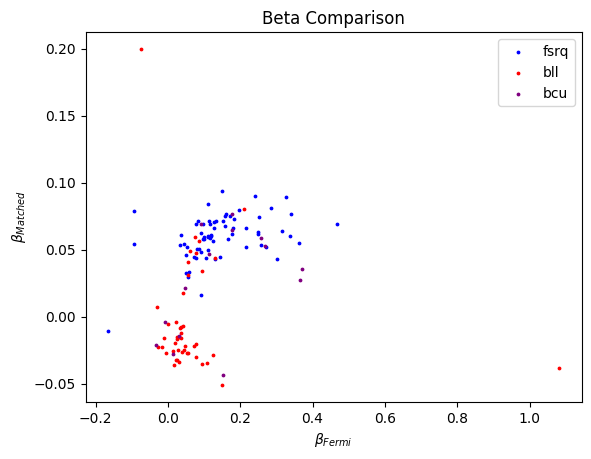

In [43]:
for i in range(len(Matched_Fits_Fermi_all)):
    beta_Fermi_only = Matched_Fits_Fermi_all[i]['Beta'].tolist()
    beta_matched = Matched_Blazar_Fit_Catalogs_by_class[i]['Beta'].tolist()

    plt.scatter(beta_Fermi_only, beta_matched, color = colors[i], label = labels[i], s = 3)

plt.xlabel(r'$\beta_{Fermi}$')
plt.ylabel(r'$\beta_{Matched}$')
plt.legend(loc = 'upper right')
plt.title('Beta Comparison')

plt.savefig(outdir + 'Beta_Comparison')

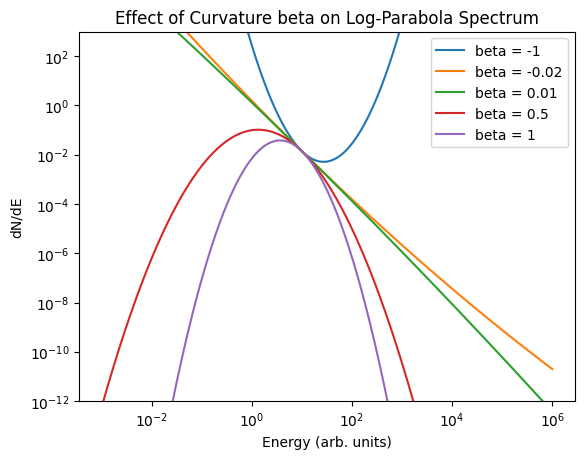

In [44]:
def log_parabola(E, A, alpha, beta, E_ref):
    return A * (E / E_ref) ** (-alpha - beta * np.log(E / E_ref))

E = np.logspace(-3, 6, 1000)  # Energy range: 0.1 to 100 (arbitrary units)
E_ref = 10
A = 0.014

for b in [-1,-0.02, 0.01, 0.5, 1]:
    y = log_parabola(E, A, alpha=2, beta=b, E_ref=E_ref)
    plt.plot(E, y, label=f'beta = {b}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (arb. units)')
plt.ylabel('dN/dE')
plt.ylim(1e-12, 1000)
plt.title('Effect of Curvature beta on Log-Parabola Spectrum')
plt.legend()
#plt.grid(True, which='both')
plt.savefig(outdir + 'effect_beta')
plt.show()


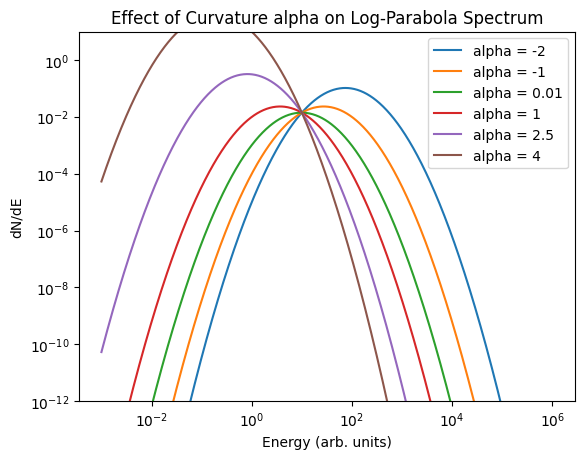

In [45]:
def log_parabola(E, A, alpha, beta, E_ref):
    return A * (E / E_ref) ** (-alpha - beta * np.log(E / E_ref))

E = np.logspace(-3, 6, 1000)  # Energy range: 0.1 to 100 (arbitrary units)
E_ref = 10
A = 0.014

for a in [-2, -1, 0.01, 1, 2.5, 4]:
    y = log_parabola(E, A, alpha=a, beta=.5, E_ref=E_ref)
    plt.plot(E, y, label=f'alpha = {a}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (arb. units)')
plt.ylabel('dN/dE')
plt.ylim(1e-12, 10)
plt.title('Effect of Curvature alpha on Log-Parabola Spectrum')
plt.legend()
#plt.grid(True, which='both')
plt.savefig(outdir + 'effect_alpha ')
plt.show()

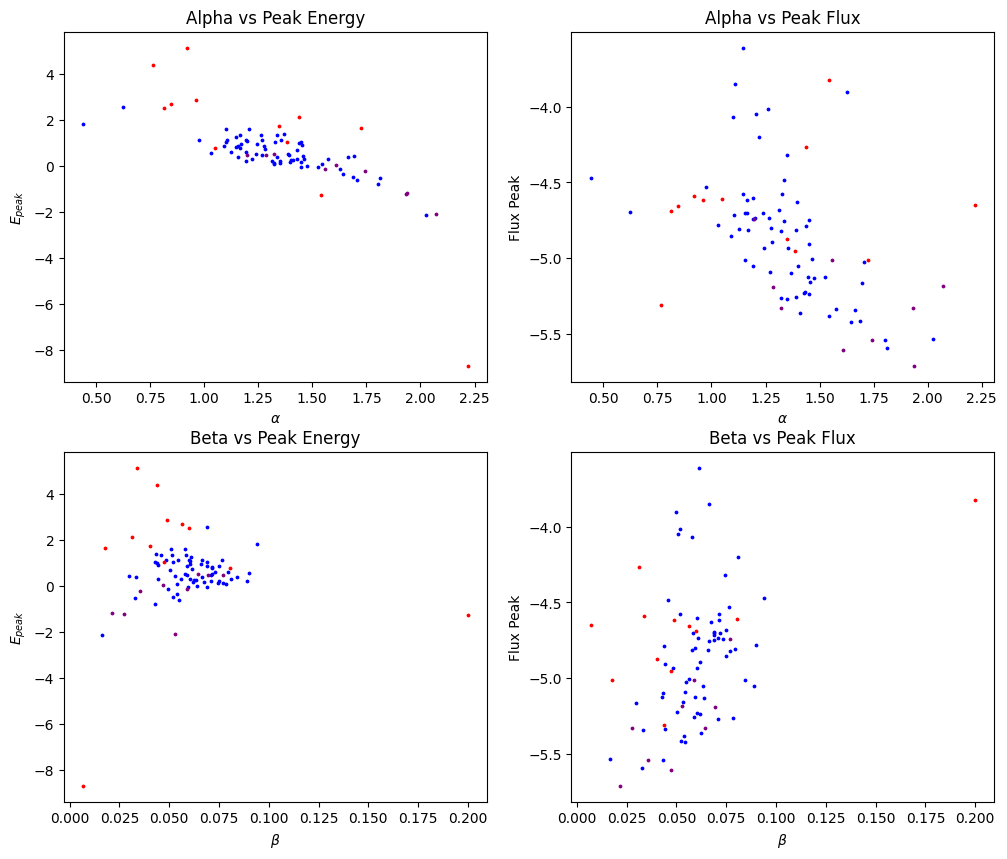

In [46]:
plt.figure(figsize=(12, 10))

for i in range(len(Matched_Blazar_Fit_Catalogs_by_class)):

    IC_peak_energies = Matched_Blazar_Fit_Catalogs_by_class[i]['IC_Peak_Energy'].tolist()
    alpha_by_class = []
    beta_by_class = []
    IC_peak_by_class = []
    IC_peak_flux_by_class = []

    for x in range(len(IC_peak_energies)):

        if IC_peak_energies[x] != 'None':
            IC_peak_by_class.append(np.log10(float(IC_peak_energies[x])))
            alpha_by_class.append(Matched_Blazar_Fit_Catalogs_by_class[i]['Alpha'].tolist()[x])
            beta_by_class.append(Matched_Blazar_Fit_Catalogs_by_class[i]['Beta'].tolist()[x])
            IC_peak_flux_by_class.append(np.log10(float(Matched_Blazar_Fit_Catalogs_by_class[i]['IC_Peak_Energy_Flux'].tolist()[x])))

    plt.subplot(2,2,1)
    plt.scatter(alpha_by_class,IC_peak_by_class,color=colors[i],label=labels[i], s= 3)
    plt.title('Alpha vs Peak Energy')
    plt.xlabel(r'$\alpha$')
    plt.ylabel('$E_{peak}$')

    plt.subplot(2,2,2)
    plt.scatter(alpha_by_class,IC_peak_flux_by_class,color=colors[i],label=labels[i], s =3)
    plt.title('Alpha vs Peak Flux')
    plt.xlabel(r'$\alpha$')
    plt.ylabel('Flux Peak')

    plt.subplot(2,2,3)
    plt.scatter(beta_by_class,IC_peak_by_class,color=colors[i],label=labels[i], s =3)
    plt.title('Beta vs Peak Energy')
    plt.xlabel(r'$\beta$')
    plt.ylabel('$E_{peak}$')

    plt.subplot(2,2,4)
    plt.scatter(beta_by_class,IC_peak_flux_by_class,color=colors[i],label=labels[i], s =3)
    plt.title('Beta vs Peak Flux')
    plt.xlabel(r'$\beta$')
    plt.ylabel('Flux Peak')

plt.savefig(outdir + 'Fit_Parameters_peak_values.png', bbox_inches='tight')

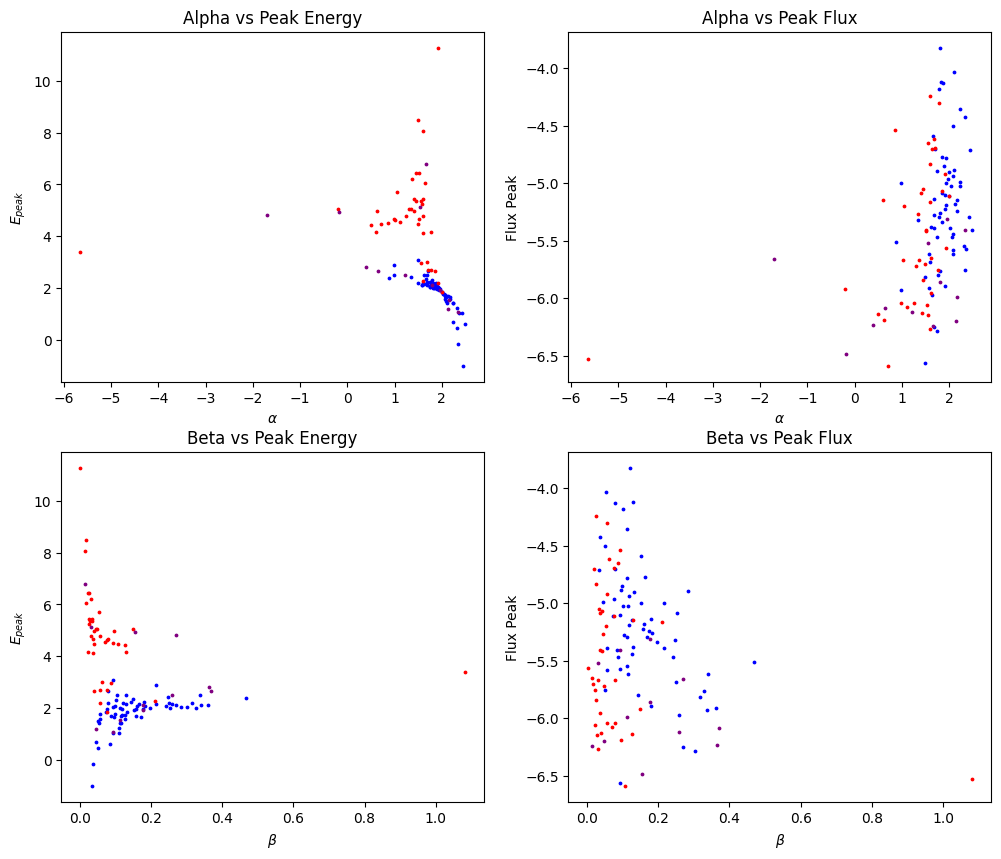

In [47]:
plt.figure(figsize=(12, 10))

for i in range(len(Matched_Blazar_Fit_Catalogs_by_class)):

    IC_peak_energies = Matched_Fits_Fermi_all[i]['IC_Peak_Energy'].tolist()
    alpha_by_class = []
    beta_by_class = []
    IC_peak_by_class = []
    IC_peak_flux_by_class = []

    for x in range(len(IC_peak_energies)):

        if IC_peak_energies[x] != 'None':
            IC_peak_by_class.append(np.log10(float(IC_peak_energies[x])))
            alpha_by_class.append(Matched_Fits_Fermi_all[i]['Alpha'].tolist()[x])
            beta_by_class.append(Matched_Fits_Fermi_all[i]['Beta'].tolist()[x])
            IC_peak_flux_by_class.append(np.log10(float(Matched_Fits_Fermi_all[i]['IC_Peak_Energy_Flux'].tolist()[x])))

    plt.subplot(2,2,1)
    plt.scatter(alpha_by_class,IC_peak_by_class,color=colors[i],label=labels[i], s= 3)
    plt.title('Alpha vs Peak Energy')
    plt.xlabel(r'$\alpha$')
    plt.ylabel('$E_{peak}$')

    plt.subplot(2,2,2)
    plt.scatter(alpha_by_class,IC_peak_flux_by_class,color=colors[i],label=labels[i], s =3)
    plt.title('Alpha vs Peak Flux')
    plt.xlabel(r'$\alpha$')
    plt.ylabel('Flux Peak')

    plt.subplot(2,2,3)
    plt.scatter(beta_by_class,IC_peak_by_class,color=colors[i],label=labels[i], s =3)
    plt.title('Beta vs Peak Energy')
    plt.xlabel(r'$\beta$')
    plt.ylabel('$E_{peak}$')

    plt.subplot(2,2,4)
    plt.scatter(beta_by_class,IC_peak_flux_by_class,color=colors[i],label=labels[i], s =3)
    plt.title('Beta vs Peak Flux')
    plt.xlabel(r'$\beta$')
    plt.ylabel('Flux Peak')

plt.savefig(outdir + 'Fermi_Only_Fit_Parameters_peak_values.png', bbox_inches='tight')